# Noise Handling Experiments

This notebook isolates the effect of the `no_noise` parameter in `CoreSG`.
It compares the default MST-based label propagation (`no_noise=True`) against the original HDBSCAN-style behavior (`no_noise=False`).


## 1. Imports


In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

from core_sg import CoreSGClusterer


## 2. Synthetic dataset with a few bridge / ambiguous points

The dataset below starts from two dense blobs and appends a few points between them so we can inspect whether final `-1` labels are preserved or reassigned.


In [11]:
X_base, _ = make_blobs(
    n_samples=600,
    n_features=2,
    centers=[(-2.5, 0.0), (2.5, 0.0)],
    cluster_std=[0.55, 0.55],
    random_state=42,
)

bridge_points = np.array(
    [
        [-0.60, 0.05],
        [-0.15, -0.10],
        [0.20, 0.10],
        [0.65, -0.05],
        [0.00, 0.75],
        [0.00, -0.75],
    ],
    dtype=np.float64,
)

X = np.vstack([X_base, bridge_points])
X.shape


(606, 2)

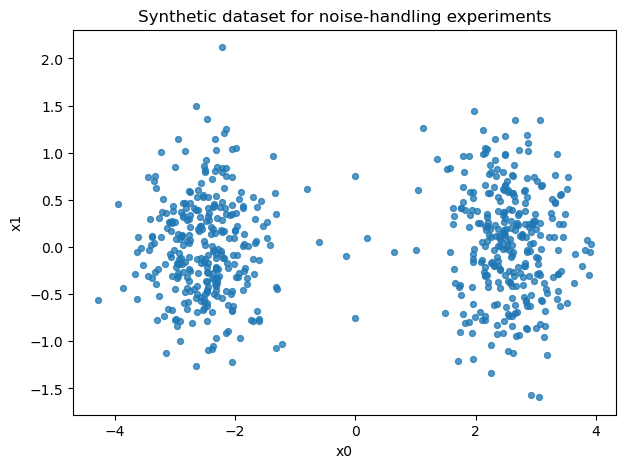

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=18, alpha=0.75)
plt.title("Synthetic dataset for noise-handling experiments")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()


## 3. Compare `no_noise=False` versus `no_noise=True`

Both runs use the same data and the same extracted `k`. The only difference is whether the post-processing step is allowed to reassign points originally labeled as `-1`.


In [13]:
k_max = 20
k_extract = 12

core_keep_noise_clusterer = CoreSGClusterer(k_max=k_max, 
    metric="euclidean",
    p=2,
    verbose=0,
    no_noise=False,
    match_reference_implementation=True,
)
core_keep_noise_clusterer.fit(X, k=k_extract)
core_keep_noise = core_keep_noise_clusterer.core_sg_

core_reassign_noise_clusterer = CoreSGClusterer(k_max=k_max, 
    metric="euclidean",
    p=2,
    verbose=0,
    no_noise=True,
    noise_label_strategy="mst_label_propagation",
    match_reference_implementation=True,
)
core_reassign_noise_clusterer.fit(X, k=k_extract)
core_reassign_noise = core_reassign_noise_clusterer.core_sg_


In [14]:
labels_keep_noise = core_keep_noise.labels_
labels_reassign_noise = core_reassign_noise.labels_

print("Noise labels with no_noise=False:", int(np.sum(labels_keep_noise == -1)))
print("Noise labels with no_noise=True:", int(np.sum(labels_reassign_noise == -1)))
print("Points reassigned by the post-processing step:", int(np.sum((labels_keep_noise == -1) & (labels_reassign_noise != -1))))


Noise labels with no_noise=False: 5
Noise labels with no_noise=True: 0
Points reassigned by the post-processing step: 5


## 4. Visual comparison


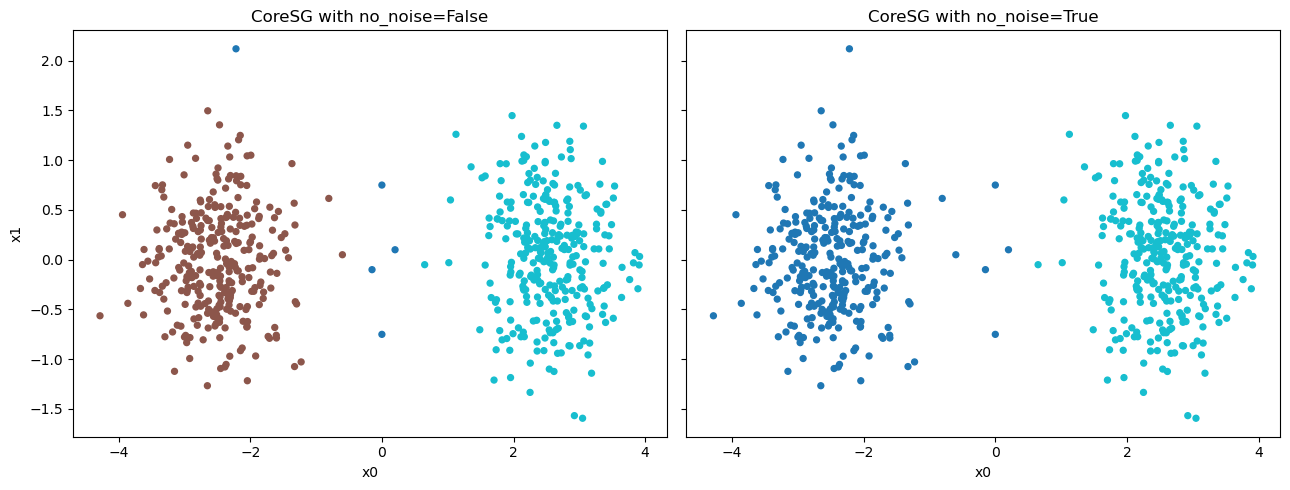

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

axes[0].scatter(X[:, 0], X[:, 1], c=labels_keep_noise, s=18, cmap="tab10")
axes[0].set_title("CoreSG with no_noise=False")
axes[0].set_xlabel("x0")
axes[0].set_ylabel("x1")

axes[1].scatter(X[:, 0], X[:, 1], c=labels_reassign_noise, s=18, cmap="tab10")
axes[1].set_title("CoreSG with no_noise=True")
axes[1].set_xlabel("x0")

plt.tight_layout()
plt.show()


## 5. Inspect only the reassigned points

This final view highlights the points that were originally noise under the HDBSCAN-style behavior and then received a propagated label.


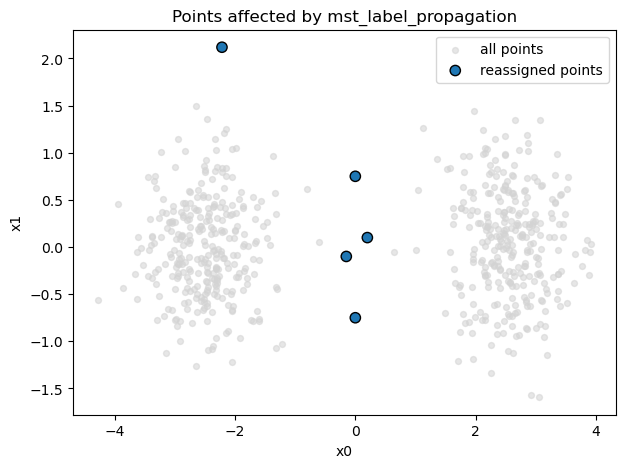

In [16]:
# Code
reassigned_mask = (labels_keep_noise == -1) & (labels_reassign_noise != -1)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c="lightgray", s=18, alpha=0.55, label="all points")
plt.scatter(
    X[reassigned_mask, 0],
    X[reassigned_mask, 1],
    c=labels_reassign_noise[reassigned_mask],
    s=55,
    cmap="tab10",
    edgecolor="black",
    label="reassigned points",
)
plt.title("Points affected by mst_label_propagation")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()
